# 프로젝트: 한영 번역기 만들기
## 1. 준비 (한글 포트)

In [96]:
!sudo apt update
!sudo apt-get install -y fonts-nanum
!pip install sentencepiece

Hit:1 http://security.ubuntu.com/ubuntu noble-security InRelease
Hit:2 http://archive.ubuntu.com/ubuntu noble InRelease0m
Hit:3 http://archive.ubuntu.com/ubuntu noble-updates InRelease
Hit:4 http://archive.ubuntu.com/ubuntu noble-backports InRelease
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
125 packages can be upgraded. Run 'apt list --upgradable' to see them.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 125 not upgraded.


In [97]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams["font.family"] = fontprop.get_name()

print(f"설정된 폰트: {fontprop.get_name()}")

설정된 폰트: NanumBarunGothic


# 2. 데이터 전처리

## 데이터 준비하기

### 라이브러리 import

In [4]:
import os
import re
import urllib.request
import zipfile
import sentencepiece as spm
import pandas as pd
import matplotlib

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

from tqdm import tqdm
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(pd.__version__)
print(torch.__version__)
print(matplotlib.__version__)

2.3.0
2.7.1+cu118
3.10.3


## 데이터 다운로드
아래 링크에서 korean-english-park.train.tar.gz 를 다운로드받아 한영 병렬 데이터를 확보합니다.

- [jungyeul/korean-parallel-corpora](https://github.com/jungyeul/korean-parallel-corpora/tree/master/korean-english-news-v1)

In [5]:
import requests
import tarfile

save_dir = os.path.expanduser("work/s2s_translation/datasets")
filename = "korean-english-park.train.tar.gz"
url = "https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz"

# 전체 파일 경로 만들기 (운영체제에 맞게 경로 결합)
file_path = os.path.join(save_dir, filename)

# 파일일 없으면 파일 다운로드
if not os.path.exists(file_path):

    # 디렉토리(폴더)가 없으면 생성
    # exist_ok=True: 폴더가 이미 있어도 에러를 내지 않음
    os.makedirs(save_dir, exist_ok=True)

    print(f"'{save_dir}' 경로에 다운로드를 시작합니다...")

    # 다운로드 실행
    response = requests.get(url, stream=True)

    if response.status_code == 200:
        with open(file_path, 'wb') as f:
            for chunk in response.iter_content(chunk_size=1024):
                f.write(chunk)
        print(f"다운로드 완료! 저장 위치: {file_path}")
    else:
        print(f"다운로드 실패. 상태 코드: {response.status_code}")


data_folder = os.path.join(save_dir, "kor-eng")
en_path_to_file = os.path.join(data_folder, "korean-english-park.train.en")
ko_path_to_file = os.path.join(data_folder, "korean-english-park.train.ko")

if not os.path.exists(en_path_to_file):
    try:
        print("압축 해제 중...")

        with tarfile.open(file_path, "r:gz") as tar:  # 'r:gz' 모드는 gzip으로 압축된 tar 파일을 읽겠다는 의미입니다.
            tar.extractall(path=data_folder)

        print("압축 해제 완료!")

    except Exception as e:
        print(f"오류 발생: {e}")

print("생성된 파일: ", os.listdir(data_folder))

생성된 파일:  ['korean-english-park.train.ko', 'korean-english-park.train.en']


In [6]:
# 줄바꿈 기준으로 5줄 출력 함수

def print_5line(contents):
    lines = contents.splitlines() # 줄바꿈을 기준으로 나누어 리스트 생성
    for line in lines[:5]:  # 처음 5개 요소(5줄)를 출력
        print(line)

In [7]:
with open(ko_path_to_file, 'r', encoding='utf-8') as file:
    ko_contents = file.read()  # 파일 내용 읽기
    print_5line(ko_contents)   # 확인용 5줄 출력

개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하지 않는다.
그러나 이것은 또한 책상도 필요로 하지 않는다.
79.95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목, 팔, 그외에 어떤 부분이든 그 움직임에따라 커서의 움직임을 조절하는 회전 운동 센서를 사용하고 있다.
정보 관리들은 동남 아시아에서의 선박들에 대한 많은 (테러) 계획들이 실패로 돌아갔음을 밝혔으며, 세계 해상 교역량의 거의 3분의 1을 운송하는 좁은 해로인 말라카 해협이 테러 공격을 당하기 쉽다고 경고하고 있다.


In [8]:
with open(en_path_to_file, 'r', encoding='utf-8') as file:
    en_contents = file.read()  # 파일 내용 읽기
    print_5line(en_contents)   # 확인용 5줄 출력

Much of personal computing is about "can you top this?"
so a mention a few weeks ago about a rechargeable wireless optical mouse brought in another rechargeable, wireless mouse.
Like all optical mice, But it also doesn't need a desk.
uses gyroscopic sensors to control the cursor movement as you move your wrist, arm, whatever through the air.
Intelligence officials have revealed a spate of foiled plots on ships in Southeast Asia and are warning that a narrow stretch of water carrying almost one third of the world's maritime trade is vulnerable to a terror attack.


## 데이터 전처리: 정제하기

In [9]:
kor_list = ko_contents.split("\n")
eng_list = en_contents.split("\n")

In [10]:
# (kor, eng) 쌍을 튜플로 묶어서 set으로 중복 제거
# cleaned_corpus = list(set(zip(kor_list, eng_list)))  # set 처리후 kor, eng 쌍 이상함
cleaned_corpus = list(zip(kor_list, eng_list))


In [11]:
# 결과 확인
print(f"중복 제거 전: {len(kor_list)}개")
print(f"중복 제거 후: {len(cleaned_corpus)}개")

중복 제거 전: 94124개
중복 제거 후: 94124개


In [12]:
# 데이터프레임 생성 후 상위 5개 출력
df_sample = pd.DataFrame(cleaned_corpus, columns=['Korean', 'English'])
df_sample.head()

,Korean,English
0,"개인용 컴퓨터 사용의 상당 부분은 ""이것보다 뛰어날 수 있느냐?""","Much of personal computing is about ""can you t..."
1,모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...,so a mention a few weeks ago about a rechargea...
2,그러나 이것은 또한 책상도 필요로 하지 않는다.,"Like all optical mice, But it also doesn't nee..."
3,"79.95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목, 팔, 그외에 어떤 부분...",uses gyroscopic sensors to control the cursor ...
4,정보 관리들은 동남 아시아에서의 선박들에 대한 많은 (테러) 계획들이 실패로 돌아갔...,Intelligence officials have revealed a spate o...


In [13]:
df_sample['Korean'][94122]

'경찰은 김회장의 집무실에서 추가 증거를 찾은 이후 가능한 한 오늘 김회장과 아들을 구속수사 할 방침이다.'

In [14]:
df_sample['English'][94122]

'Police are planning to seek arrest warrants for Kim and his son as early as today, after searching the premises and securing additional material evidence.'

In [15]:
df_sample.shape

(94124, 2)

In [16]:
def preprocess_sentence(sentence):
    sentence = sentence.lower().strip()

    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = re.sub(r"[^가-힣a-zA-Z?.!,]+", " ", sentence)

    sentence = sentence.strip()

    return sentence

print("슝~")

슝~


In [17]:
# 상위 3만 개만 사용

df = df_sample[:30000]

df["Korean"] = df["Korean"].apply(preprocess_sentence)
df["English"] = df["English"].apply(lambda x: preprocess_sentence(x))

df.head()

/tmp/ipykernel_196/3199512482.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Korean"] = df["Korean"].apply(preprocess_sentence)
/tmp/ipykernel_196/3199512482.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["English"] = df["English"].apply(lambda x: preprocess_sentence(x))


,Korean,English
0,개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐 ?,much of personal computing is about can you to...
1,모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...,so a mention a few weeks ago about a rechargea...
2,그러나 이것은 또한 책상도 필요로 하지 않는다 .,"like all optical mice , but it also doesn t ne..."
3,". 달러하는 이 최첨단 무선 광마우스는 허공에서 팔목 , 팔 , 그외에 어떤 부분이...",uses gyroscopic sensors to control the cursor ...
4,정보 관리들은 동남 아시아에서의 선박들에 대한 많은 테러 계획들이 실패로 돌아갔음을...,intelligence officials have revealed a spate o...


### 한글 - KoNLPy의 Mecab 클래스를 사용

In [ ]:
!pip install konlpy

In [ ]:
from konlpy.tag import Mecab
mecab = Mecab()
test_sentence = mecab.morphs("아버지가 방에 들어갑니다.")
print("✅ Mecab 정상 동작:", test_sentence)
# 출력: ['아버지', '가', '방', '에', '들어가', '다', '.']

Exception: Install MeCab in order to use it: http://konlpy.org/en/latest/install/

## 데이터 전처리: 토큰화

In [18]:
# 토큰 길이 40 이하인 데이터만 선별 (모든 데이터를 사용할 경우 학습에 굉장히 오랜 시간이 걸립니다.)
mask = (
    df["Korean"].str.split(" ").str.len() <= 40  # 한국어 토큰 길이
) & (
    df["English"].str.split(" ").str.len() <= 40  # 영어 토큰 길이
)

# 필터링된 데이터프레임
filtered_df = df[mask].copy()

# Mecab 객체 생성
# mecab = Mecab() 설치 error로 사용 불가

# # filtered_df["Korean"]에 한글 문장 리스트가 있다고 가정
# with open('korean_mecab.txt', 'w', encoding='utf-8') as f:
#     for kor_sentence in filtered_df["Korean"]:

#         # Mecab으로 형태소 분리 (예: "아버지가 방에" -> ['아버지', '가', '방', '에'])
#         morphs = mecab.morphs(kor_sentence)

#         # 공백으로 합쳐서 한 줄에 저장 (예: "아버지 가 방 에")
#         # SentencePiece는 텍스트 파일을 입력으로 받기 때문
#         f.write(' '.join(morphs) + '\n')

# print("Mecab 전처리 완료! 'korean_mecab.txt' 생성됨.")
# print(f"총 {len(filtered_df)} 문장 처리됨.")

filtered_df["Korean"].to_csv("p2_kor_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")
filtered_df["English"].to_csv("p2_eng_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")

print("파일 저장 완료: p2_eng_corpus.txt, p2_kor_corpus.txt")

파일 저장 완료: p2_eng_corpus.txt, p2_kor_corpus.txt


### SentencePiece를 활용해 Tokenizer를 생성하고 테이터를 변환

In [19]:
vocab_size = 10000
pad_id = 0
bos_id = 1
eos_id = 2
unk_id = 3

spm.SentencePieceTrainer.train(
    input = "p2_kor_corpus.txt",
    model_prefix = "p2_encoder_spm",
    vocab_size = vocab_size,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)

spm.SentencePieceTrainer.train(
    input = "p2_eng_corpus.txt",
    model_prefix = "p2_decoder_spm",
    vocab_size = vocab_size,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)

sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: p2_kor_corpus.txt
  input_format: 
  model_prefix: p2_encoder_spm
  model_type: UNIGRAM
  vocab_size: 10000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy

In [20]:
encoder_tokenizer = spm.SentencePieceProcessor()
encoder_tokenizer.load("p2_encoder_spm.model")

decoder_tokenizer = spm.SentencePieceProcessor()
decoder_tokenizer.load("p2_decoder_spm.model")

True

### 데이타 확인

In [21]:
df

,Korean,English
0,개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐 ?,much of personal computing is about can you to...
1,모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...,so a mention a few weeks ago about a rechargea...
2,그러나 이것은 또한 책상도 필요로 하지 않는다 .,"like all optical mice , but it also doesn t ne..."
3,". 달러하는 이 최첨단 무선 광마우스는 허공에서 팔목 , 팔 , 그외에 어떤 부분이...",uses gyroscopic sensors to control the cursor ...
4,정보 관리들은 동남 아시아에서의 선박들에 대한 많은 테러 계획들이 실패로 돌아갔음을...,intelligence officials have revealed a spate o...
...,...,...
29995,일각에서는 대법원이 무샤라프의 당선은 무효라는 판결을 내릴 경우 그가 계엄령을 선포...,a majority a vast majority have voted for me a...
29996,미국 위스콘신 주 크랜든에서 일 오전 현지시간 비번이던 보안관이 총기를 난사해 명이...,cnn an off duty sheriff s deputy shot and kill...
29997,용의자는 타일러 피터슨은 크랜든 보안관겸 비 상근직 경찰로 근무해 온 것으로 알려졌다 .,"the deputy , tyler peterson , also worked part..."
29998,케이스 반 클레브 포레스트카운티 보안관은 피터슨이 대였다고 전했다 .,forest county sheriff keith van cleve said pet...


In [22]:
eng_sample = df["English"][1000]
kor_sample = df["Korean"][1000]
print(eng_sample)
print('-' * 10)
print(kor_sample)

but these days that rationale is being questioned .
----------
그러나 요즈음에 그러한 이론적 해석이 의문시되고 있다 .


In [23]:
enc_token = encoder_tokenizer.encode(eng_sample)
enc_token = [encoder_tokenizer.bos_id()] + enc_token + [encoder_tokenizer.eos_id()]
enc_token

[1,
 818,
 499,
 506,
 487,
 2269,
 4,
 4439,
 208,
 4,
 3039,
 2771,
 2159,
 1772,
 702,
 445,
 4,
 1654,
 2886,
 1217,
 5306,
 499,
 2480,
 3387,
 1995,
 5,
 2]

In [100]:
pieces = encoder_tokenizer.encode_as_pieces(eng_sample)
print(pieces)

['▁b', 'u', 't', '▁the', 'se', '▁', 'day', 's', '▁', 'th', 'at', '▁r', 'ation', 'al', 'e', '▁', 'is', '▁be', 'ing', '▁q', 'u', 'es', 'tion', 'ed', '▁.']


In [24]:
enc_decoding = encoder_tokenizer.decode(enc_token)
enc_decoding

'but these days that rationale is being questioned .'

In [25]:
kor_token = encoder_tokenizer.encode(kor_sample)
kor_token = [encoder_tokenizer.bos_id()] + kor_token + [encoder_tokenizer.eos_id()]
kor_token

[1, 69, 8383, 12, 1419, 16, 3654, 253, 7293, 11, 3660, 94, 507, 23, 5, 2]

In [101]:
pieces = encoder_tokenizer.encode_as_pieces(kor_sample)
print(pieces)

['▁그러나', '▁요즈음', '에', '▁그러', '한', '▁이론', '적', '▁해석', '이', '▁의문', '시', '되고', '▁있다', '▁.']


In [26]:
kor_decoding = encoder_tokenizer.decode(kor_token)
kor_decoding

'그러나 요즈음에 그러한 이론적 해석이 의문시되고 있다 .'

### 데이터셋 생성
START_TOKEN, END_TOKEN 추가 + Padding

In [27]:
class TranslationDataset(Dataset):
    def __init__(self, data, encoder_tokenizer, decoder_tokenizer, max_len):
        self.data = data
        self.encoder_tokenizer = encoder_tokenizer
        self.decoder_tokenizer = decoder_tokenizer
        self.max_len = max_len
        self.pad_id = 0
        self.bos_id = 1
        self.eos_id = 2

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        src_text = self.data.iloc[idx]['Korean']
        trg_text = self.data.iloc[idx]['English']

        src_ids = self.encoder_tokenizer.encode(src_text)
        trg_ids = self.decoder_tokenizer.encode(trg_text)

        src_ids = src_ids[:self.max_len]

        # Decoder의 입력에는 START_TOKEN과 END_TOKEN을 추가해줍니다. 단, 최대 길이 제한을 적용시킵니다.
        trg_input = [self.bos_id] + trg_ids[:self.max_len - 2] + [self.eos_id]
        trg_label = trg_ids[:self.max_len - 1] + [self.eos_id]

        # 길이가 짧은 경우 PAD_TOKEN을 추가해줍니다.
        src_ids = src_ids + [self.pad_id] * (self.max_len - len(src_ids))
        trg_input = trg_input + [self.pad_id] * (self.max_len - len(trg_input))
        trg_label = trg_label + [self.pad_id] * (self.max_len - len(trg_label))

        return torch.tensor(src_ids), torch.tensor(trg_input), torch.tensor(trg_label)

### train data 준비 (난이도에 비해 데이터가 많지 않아 훈련 데이터와 검증 데이터를 따로 나누지는 않습니다.)

In [28]:
MAX_LEN = 40 # 임의의 값
BATCH_SIZE = 64

train_data = df.copy()

train_data.reset_index(drop=True, inplace=True)

train_data = TranslationDataset(train_data, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
validation_loader = None  # 또는 []

In [29]:
for src, trg_input, trg_label in train_loader:
    print(src.shape, trg_input.shape, trg_label.shape)
    break

torch.Size([64, 40]) torch.Size([64, 40]) torch.Size([64, 40])


## 3. 모델 설계
### Bahdanau Attention 설계

In [81]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: (1, batch_size, hidden_dim) 또는 (batch_size, hidden_dim)으로 올 수 있음
        # LSTM hidden state는 (num_layers, batch_size, hidden_dim) 형태이므로, 첫 번째 차원(레이어)을 제거합니다.
        if hidden.dim() == 3:
            hidden = hidden.squeeze(0) # (batch_size, hidden_dim)

        # encoder_outputs: (batch_size, src_len, hidden_dim) (Encoder에서 batch_first=True로 오기 때문에)

        # src_len을 encoder_outputs의 두 번째 차원(원본 src_len)에서 가져옵니다.
        src_len = encoder_outputs.shape[1] # <--- 수정: shape[0] 대신 shape[1]

        # hidden을 (batch_size, src_len, hidden_dim) 형태로 확장합니다.
        hidden_for_attention = hidden.unsqueeze(1).repeat(1, src_len, 1) # (batch_size, src_len, hidden_dim)

        # encoder_outputs는 이미 (batch_size, src_len, hidden_dim) 형태이므로 permute가 필요 없습니다.
        # 기존: encoder_outputs = encoder_outputs.permute(1, 0, 2) # 이 줄을 제거합니다.

        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden_for_attention))  # (batch_size, src_len, hidden_dim)
        attention = self.v(energy).squeeze(2)  # (batch_size, src_len)

        return nn.functional.softmax(attention, dim=1)  # (batch_size, src_len)

### Encoder, Decoder 설계

In [82]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim)
        # batch_first=False로 변경 (또는 embedded.permute(1, 0, 2)를 forward에서 추가)
        self.rnn = nn.LSTM(emb_dim, hidden_dim, batch_first=True)  # =False)

    def forward(self, src):
        # src : (src_len, batch_size)
        embedded = self.embedding(src)  # embedded : (src_len, batch_size, emb_dim)

        # 만약 batch_first=True를 유지하고 싶다면 아래 라인의 주석을 해제
        embedded = embedded.permute(1, 0, 2) # (batch_size, src_len, emb_dim)

        outputs, (h_0, c_0) = self.rnn(embedded)  # outputs : (src_len, batch_size, hidden_dim) (batch_first=False일 경우)
                                                  # 또는 (batch_size, src_len, hidden_dim) (batch_first=True이고 embedded를 permute한 경우)
        # h_0, c_0 : (1, batch_size, hidden_dim)  # num_layers * num_directions, batch, hidden_dim

        return outputs, h_0, c_0

In [83]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super(Decoder, self).__init__()

        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        # Decoder RNN에는 embedding과 context vector가 결합되어 입력
        self.rnn =  nn.LSTM(emb_dim + hidden_dim, hidden_dim, batch_first=True)
        # 출력층에는 hidden state와 attention value가 결합되어 입력
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, cell, encoder_outputs):
        # input : (batch_size,)
        # hidden : (batch_size, hidden_dim)
        # encoder_outputs : (batch_size, src_len, hidden_dim)
        input = input.unsqueeze(0)  # input : (1, batch_size)
        embedded = self.embedding(input)  # embedded : (1, batch_size, emb_dim)

        # attention distribution을 계산합니다.
        a = self.attention(hidden, encoder_outputs)  # a : (batch_size, src_len)

        # H에 가중치를 부여해 attention value(Context vector) 계산
        a = a.unsqueeze(1)  # a : (batch_size, 1, src_len)
        # encoder_outputs는 이미 (batch_size, src_len, hidden_dim) 형태이므로 permute가 필요 없습니다. 이 줄을 제거합니다.
        # encoder_outputs = encoder_outputs.permute(1, 0, 2)
        context = torch.bmm(a, encoder_outputs)  # context : (batch_size, 1, hidden_dim), bmm: Batch Matrix Multiplication
        context = context.permute(1, 0, 2)  # context : (1, batch_size, hidden_dim)

        # embedded와 context를 결합하여 RNN에 전달
        rnn_input = torch.cat((embedded, context), dim=2) # (1, batch_size, emb_dim + hidden_dim)
        # rnn_input을 (batch_size, 1, emb_dim + hidden_dim) 형태로 permute합니다. (batch_first=True를 위해)
        rnn_input = rnn_input.permute(1, 0, 2)

        output, (hidden, cell) = self.rnn(rnn_input, (hidden, cell))

        # 출력층에서는 현재 hidden state와 context vector를 결합하여 예측값 생성
        output = output.squeeze(1)  # output : (batch_size, hidden_dim)  <-- 여기를 squeeze(1)로 변경합니다.
        context = context.squeeze(0)  # context : (batch_size, hidden_dim)
        prediction = self.fc_out(torch.cat((output, context), dim=1))  # (batch_size, output_dim)

        return prediction, hidden, cell, a.squeeze(1)

### Seq2SeqAttention model 설계

In [84]:
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=30, bos_id = 1, eos_id=2):
        # 학습 모드에서는 trg_len 사용, 추론 모드에서는 max_len까지 동적 생성
        batch_size = src.shape[1] # src가 (src_len, batch_size) 형태라고 가정
        trg_vocab_size = self.decoder.fc_out.out_features

        # 조기 종료를 위해 tensor가 아닌 리스트 사용
        outputs = []

        # 시각화를 위해 attention 저장
        attentions = []

        # 인코더를 통해 context 생성
        encoder_outputs, hidden, cell = self.encoder(src) # h_0와 c_0를 hidden, cell로 받음

        if trg is not None:
            for t in range(0, trg.shape[0]):
                input = trg[t]
                output, hidden, cell, attention = self.decoder(input, hidden, cell, encoder_outputs) # hidden과 cell을 모두 전달
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))

        else:
		    # inference에서는 target(정답)이 없기 때문에 sos_token을 생성해줍니다.
            input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

            for t in range(max_len):
                output, hidden, cell, attention = self.decoder(input, hidden, cell, encoder_outputs) # hidden과 cell을 모두 전달
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                top1 = output.argmax(1)
                input = top1

                # 조기 종료 조건
                finished |= (top1 == eos_id)
                if finished.all():
                    break

        outputs = torch.cat(outputs, dim=0)  # (trg_len, batch_size, output_dim)
        attentions = torch.cat(attentions, dim=0)  # (trg_len, batch_size, src_len)

        return outputs, attentions

In [85]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

input_dim = len(encoder_tokenizer)
output_dim = len(decoder_tokenizer)
emb_dim = 256
hid_dim = 512

In [86]:
encoder = Encoder(input_dim, emb_dim, hid_dim).to(device)
attention = BahdanauAttention(hid_dim).to(device)
decoder = Decoder(output_dim, emb_dim, hid_dim, attention).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

In [87]:
print(model)

Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(10000, 256)
    (rnn): LSTM(256, 512, batch_first=True)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(10000, 256)
    (rnn): LSTM(768, 512, batch_first=True)
    (fc_out): Linear(in_features=1024, out_features=10000, bias=True)
  )
)


## 4. 훈련하기
### (1) Optimizer & Loss

In [88]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)

print("슝~")

슝~


### (2) train_step 구현하기

In [89]:
def train_step(model, data_loader, optimizer, criterion, epoch):
    model.train()
    epoch_loss = 0

    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    for src, trg_input, trg_label in progress_bar:
        # 모델의 입력 순서에 맞게 transpose 변환
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)
        optimizer.zero_grad()

        outputs,_ = model(src, trg_input)

        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

        optimizer.step()

        epoch_loss += loss.item()

        progress_bar.set_postfix(loss=loss.item())

    return epoch_loss / len(data_loader)

print("슝~")


슝~


### (3) 훈련 시작하기

In [90]:
def eval_step(model, data_loader, optimizer, criterion):
    model.eval()
    total_loss = 0

    for src, trg_input, trg_label in data_loader:
        # 모델의 입력 순서에 맞게 transpose 변환
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)

        outputs,_ = model(src, trg_input)

        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)

        total_loss += loss.item()

    return total_loss / len(data_loader)

print("슝~")

슝~


In [91]:
%%time

EPOCHS = 20

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    if validation_loader:
        valid_loss = eval_step(model, validation_loader, optimizer, criterion)
        print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}')
    else:
        print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}')

Epoch 1: 100%|██████████| 469/469 [01:54<00:00,  4.11it/s, loss=4.8] 


Epoch 1/20, Train Loss: 5.5704


Epoch 2: 100%|██████████| 469/469 [01:53<00:00,  4.14it/s, loss=4.35]


Epoch 2/20, Train Loss: 4.5167


Epoch 3: 100%|██████████| 469/469 [01:53<00:00,  4.14it/s, loss=3.88]


...

Epoch 18/20, Train Loss: 0.4411


Epoch 19: 100%|██████████| 469/469 [01:53<00:00,  4.13it/s, loss=0.459]


Epoch 19/20, Train Loss: 0.3851


Epoch 20: 100%|██████████| 469/469 [01:53<00:00,  4.13it/s, loss=0.396]

Epoch 20/20, Train Loss: 0.3342
CPU times: user 34min 33s, sys: 3min 26s, total: 38min
Wall time: 37min 51s


### 번역 성능 평가 + Attention Map 시각화

In [92]:
def evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=30):
    model.eval()

    sentence = preprocess_sentence(sentence)
    src_ids = encoder_tokenizer.encode(sentence)
    src_ids = src_ids[:max_len]
    src_ids = src_ids + [0] * (max_len - len(src_ids))  # 패딩 추가
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)  # (src_len, 1)

    with torch.no_grad():
        outputs, attentions = model(src_tensor, max_len=max_len)

    result = [decoder_tokenizer.decode([token.item()]) for token in outputs.argmax(2).squeeze(1)]

    if "<end>" in result:
        result = result[:result.index("<end>")]

    return result, sentence, attentions.squeeze(1).cpu().numpy()

In [93]:
def plot_attention(attention, sentence, predicted_sentence):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.matshow(attention, cmap='viridis')

    fontdict = {'fontsize': 14}

    ax.set_xticks(range(len(sentence)))
    ax.set_xticklabels(sentence, fontdict=fontdict, rotation=90)

    ax.set_yticks(range(len(predicted_sentence)))
    ax.set_yticklabels(predicted_sentence, fontdict=fontdict)

    plt.show()

In [94]:
def translate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=30):
    result, sentence, attention = evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len)

    print('Input: %s' % (sentence))
    print('Predicted translation: {}'.format(result))

    # Attention 크기 조정 (trg_len, src_len)
    attention = attention[:len(result), :len(sentence.split())]

    plot_attention(attention, sentence.split(), result)

Input: 오바마는 대통령이다 .
Predicted translation: ['the', 'president', 'has', 'be', 'en', 'aim', 'ed', 'to', 'the', 'president', 'as', 'oba', 'ma', '.', '']


/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/con

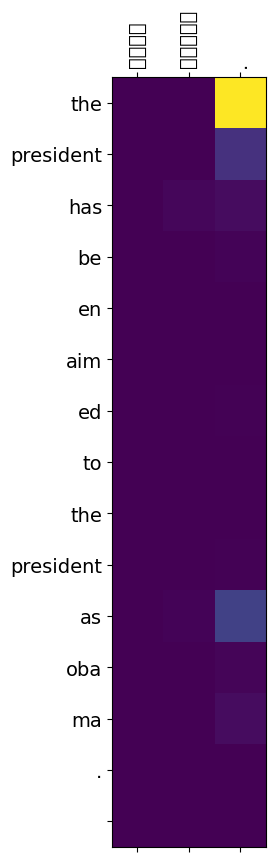

In [95]:
translate("오바마는 대통령이다.", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: 시민들은 도시 속에 산다 .
Predicted translation: ['the', 'small', 'number', 'will', 'be', 'gan', 'on', 'its', 'web', 'site', '.', '']


/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48124 (\N{HANGUL SYLLABLE MIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46308 (\N{HANGUL SYLLABLE DEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51008 (\N{HANGUL SYLLABLE EUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/c

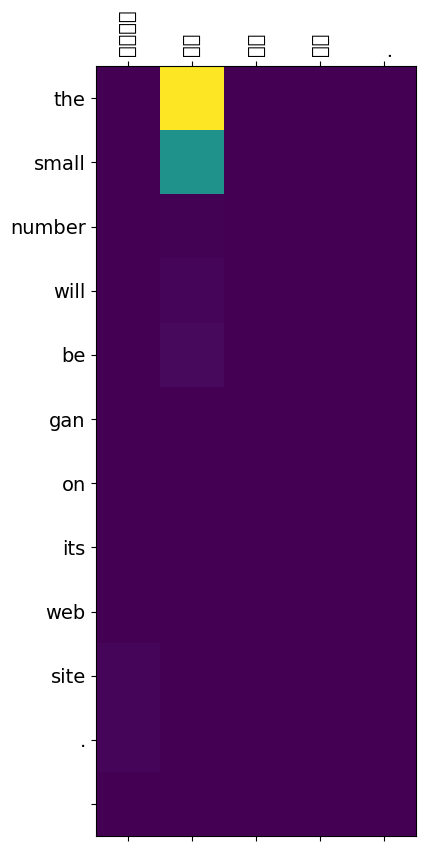

In [98]:
translate("시민들은 도시 속에 산다.", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: 커피는 필요 없다 .
Predicted translation: ['it', 's', 'that', 'it', 'will', 'be', 'that', 'does', 'n', 't', 'have', 'to', 'make', '.', '']


/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52964 (\N{HANGUL SYLLABLE KEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54596 (\N{HANGUL SYLLABLE PIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/c

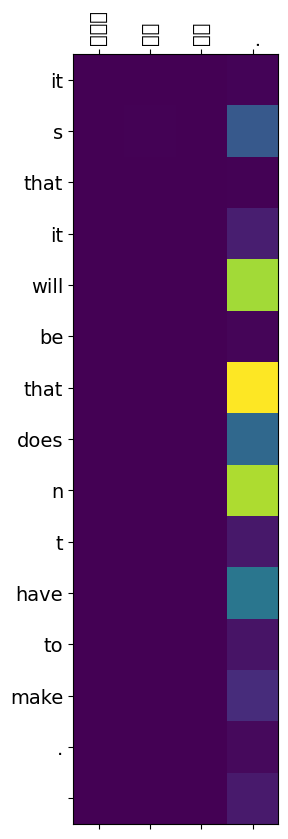

In [99]:
# 실행 예제
translate("커피는 필요 없다.", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: 일곱 명의 사망자가 발생했다 .
Predicted translation: ['the', 'death', 'toll', 'in', 'was', 'up', 'to', 'death', 's', '.', '']


/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44273 (\N{HANGUL SYLLABLE GOB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/

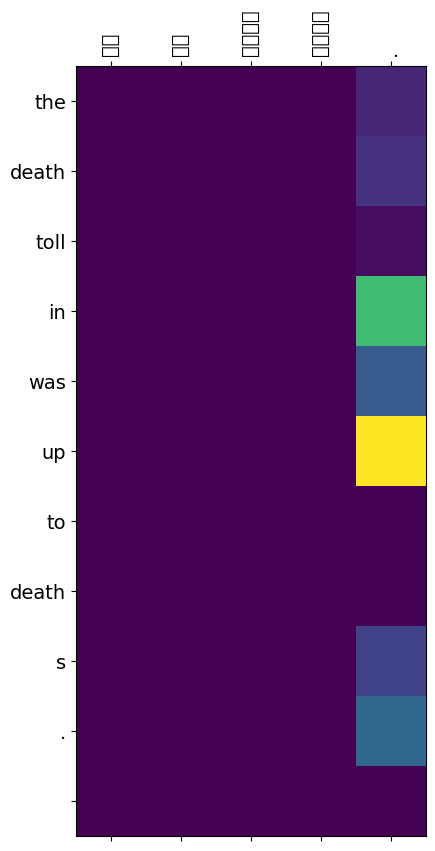

In [102]:
translate("일곱 명의 사망자가 발생했다.", model, encoder_tokenizer, decoder_tokenizer, max_len=30)